# Agricultura circular con agua de mar y sol

**0,6 hectáreas. Agua de mar. Sol.** ¿Cuántas personas puedes alimentar? La respuesta: **47.**

---

📄 **Paper:** Sun, Z. et al. *Solar-powered circular desalination agriculture enabled by amyloid fibril-based bioevaporators*  
📰 **Journal:** Nature Water (2026) — DOI: [10.1038/s44221-026-00615-y](https://doi.org/10.1038/s44221-026-00615-y)  
🔗 **Datos:** [Figshare](https://doi.org/10.6084/m9.figshare.30962279) + Source Data  
▶️ **Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-08-desalinizacion-solar-agricultura-circular/notebook.ipynb)

## El problema

La agricultura costera tiene un enemigo doble: le falta agua dulce y le sobra sal. Las plantas de desalinización por ósmosis inversa (RO) resuelven lo primero, pero consumen mucha energía y generan residuos. ¿Y si el sol hiciera todo el trabajo?

Un equipo en la isla de Hainan (sur de China) probó un sistema **circular**: destilar agua de mar con energía solar, regar cultivos, y convertir los residuos de la cosecha en nuevos evaporadores y fertilizante. Tres meses de campo. Veamos qué encontraron.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERSONAS_ALIMENTADAS = 47     # Con 0,6 ha de terreno
PROD_SOLAR = 8.29             # mm/día — productividad solar
PROD_NATURAL = 2.0            # mm/día — evaporación natural
FUENTE = 'Fuente: Sun et al. (2026), Nature Water | Datos: Figshare + Source Data'
COLOR_SOLAR = '#2563EB'       # Azul CaM — desalinización solar
COLOR_RO = '#D97706'          # Amber — ósmosis inversa
COLOR_NATURAL = '#DC2626'     # Rojo — evaporación natural / agua de mar
COLOR_REMEDIADO = '#059669'   # Emerald — suelo remediado

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Datos
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/'
BASE += '2026-04-08-desalinizacion-solar-agricultura-circular/datos/'

archivos = ['altura_plantas.csv', 'calidad_agua.csv', 'rendimiento_cultivos.csv',
            'rendimiento_soja.csv', 'estabilidad_operacion.csv', 'remediacion_suelo.csv',
            'germinacion_soja.csv']

os.makedirs('datos', exist_ok=True)
for arch in archivos:
    local = f'datos/{arch}'
    if not os.path.exists(local):
        urllib.request.urlretrieve(BASE + arch, local)

df_altura = pd.read_csv('datos/altura_plantas.csv')
df_calidad = pd.read_csv('datos/calidad_agua.csv')
df_cultivos = pd.read_csv('datos/rendimiento_cultivos.csv')
df_soja = pd.read_csv('datos/rendimiento_soja.csv')
df_estabilidad = pd.read_csv('datos/estabilidad_operacion.csv')
df_suelo = pd.read_csv('datos/remediacion_suelo.csv')
df_germinacion = pd.read_csv('datos/germinacion_soja.csv')

print(f"Datos cargados: {len(df_altura)} mediciones de altura, "
      f"{len(df_soja)} de rendimiento soja, "
      f"{len(df_cultivos)} de rendimiento multi-cultivo")
print(f"Métodos de riego: {df_altura['metodo'].unique().tolist()}")
print(f"Cultivos: {df_cultivos['cultivo'].unique().tolist()}")

Datos cargados: 315 mediciones de altura, 18 de rendimiento soja, 48 de rendimiento multi-cultivo
Métodos de riego: ['solar', 'ro', 'natural']
Cultivos: ['Brassica juncea', 'Celtuce', 'Lactuca sativa', 'Soja (Glycine max)']


## 42 días, 3 tipos de agua

Aquí está. Mismas semillas de soja, mismo suelo, mismo sol. La única diferencia: con qué las riegas.

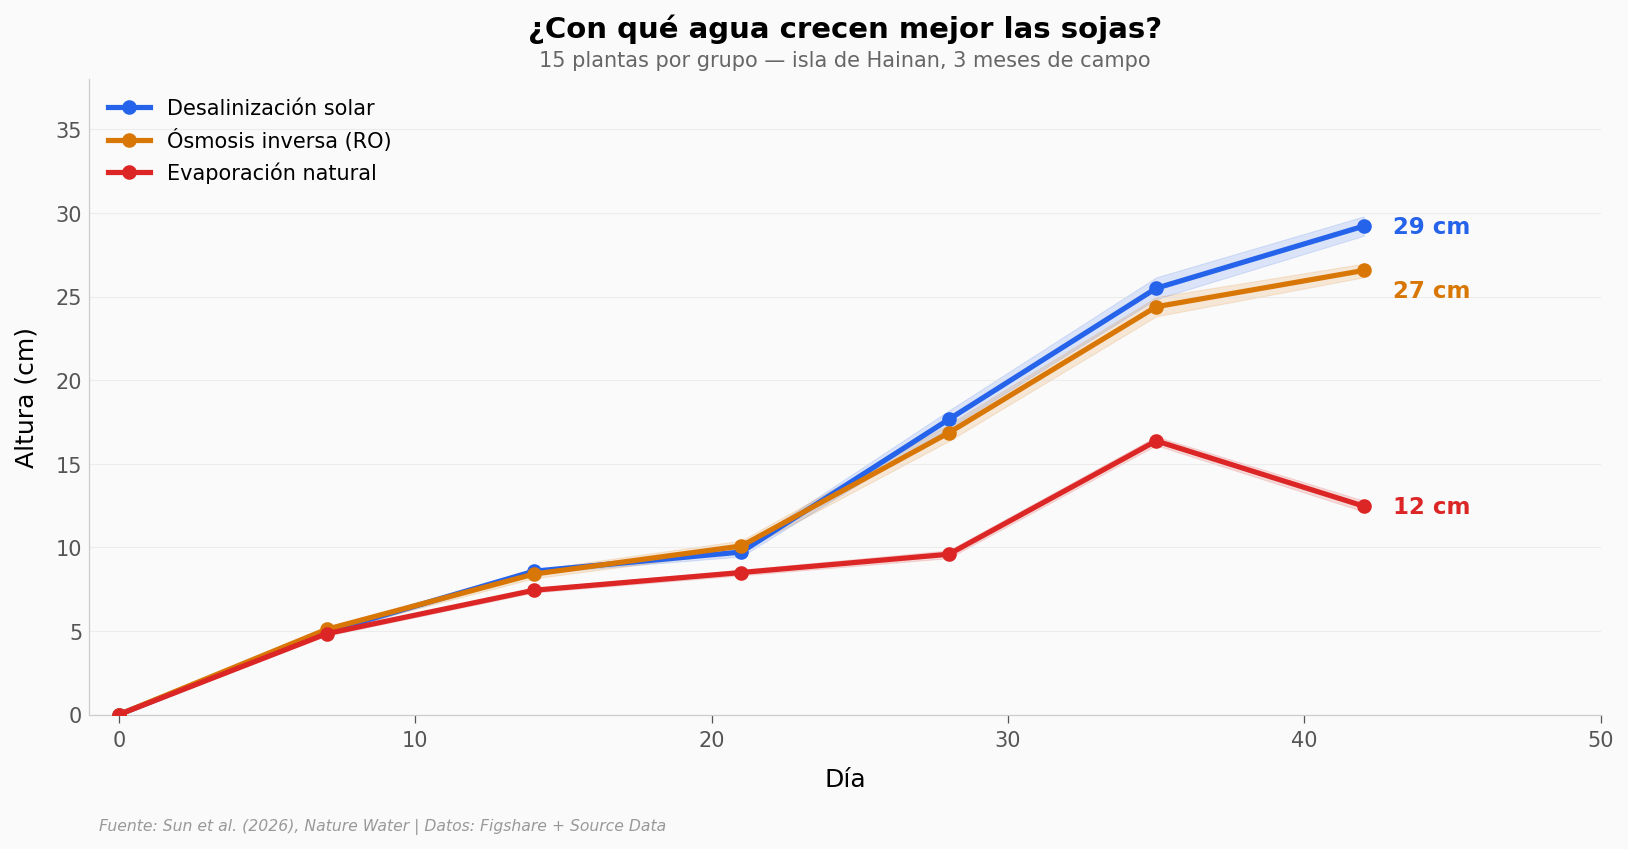

In [2]:
# Gráfica hero: crecimiento de soja bajo 3 tipos de riego
fig, ax = plt.subplots(figsize=(13, 5.5))

dias = sorted(df_altura['dia'].unique())

for metodo, color, label in [
    ('solar', COLOR_SOLAR, 'Desalinización solar'),
    ('ro', COLOR_RO, 'Ósmosis inversa (RO)'),
    ('natural', COLOR_NATURAL, 'Evaporación natural')
]:
    sub = df_altura[df_altura['metodo'] == metodo]
    medias = sub.groupby('dia')['altura_cm'].mean()
    sems = sub.groupby('dia')['altura_cm'].sem()
    ax.plot(medias.index, medias.values, '-o', color=color, linewidth=2.5,
            markersize=6, label=label, zorder=5)
    ax.fill_between(medias.index, medias.values - sems.values,
                    medias.values + sems.values, alpha=0.15, color=color)

# Inline labels al final de cada línea
solar_final = df_altura[(df_altura['metodo']=='solar') & (df_altura['dia']==42)]['altura_cm'].mean()
ro_final = df_altura[(df_altura['metodo']=='ro') & (df_altura['dia']==42)]['altura_cm'].mean()
nat_final = df_altura[(df_altura['metodo']=='natural') & (df_altura['dia']==42)]['altura_cm'].mean()

ax.text(43, solar_final, f'{solar_final:.0f} cm', color=COLOR_SOLAR,
        fontweight='bold', fontsize=11, va='center')
ax.text(43, ro_final - 1.2, f'{ro_final:.0f} cm', color=COLOR_RO,
        fontweight='bold', fontsize=11, va='center')
ax.text(43, nat_final, f'{nat_final:.0f} cm', color=COLOR_NATURAL,
        fontweight='bold', fontsize=11, va='center')

ax.set_xlabel('Día', fontsize=12)
ax.set_ylabel('Altura (cm)', fontsize=12)
ax.set_title('¿Con qué agua crecen mejor las sojas?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '15 plantas por grupo — isla de Hainan, 3 meses de campo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-1, 50)
ax.set_ylim(0, 38)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/crecimiento_soja.png', dpi=200, bbox_inches='tight')
plt.show()

Las sojas regadas con destilado solar alcanzan **29 cm** al día 42 — prácticamente lo mismo que las regadas con agua de ósmosis inversa industrial (27 cm). Pero las regadas con evaporación natural apenas llegan a **12 cm** y se estancan después del día 21.

La diferencia es enorme: las plantas solares crecen un **134%** más que las de evaporación natural (t de Welch, p < 0,0001, d = 9,21 — efecto gigante). Y lo interesante: el agua solar *supera ligeramente* al RO (Mann-Whitney p = 0,003, d = 1,37). El destilado solar no es un sustituto inferior — es competitivo.

## ¿Qué le pasa al agua de mar?

Midieron la composición del agua en cada etapa: mar crudo, RO industrial, destilado solar. Los números son brutales.

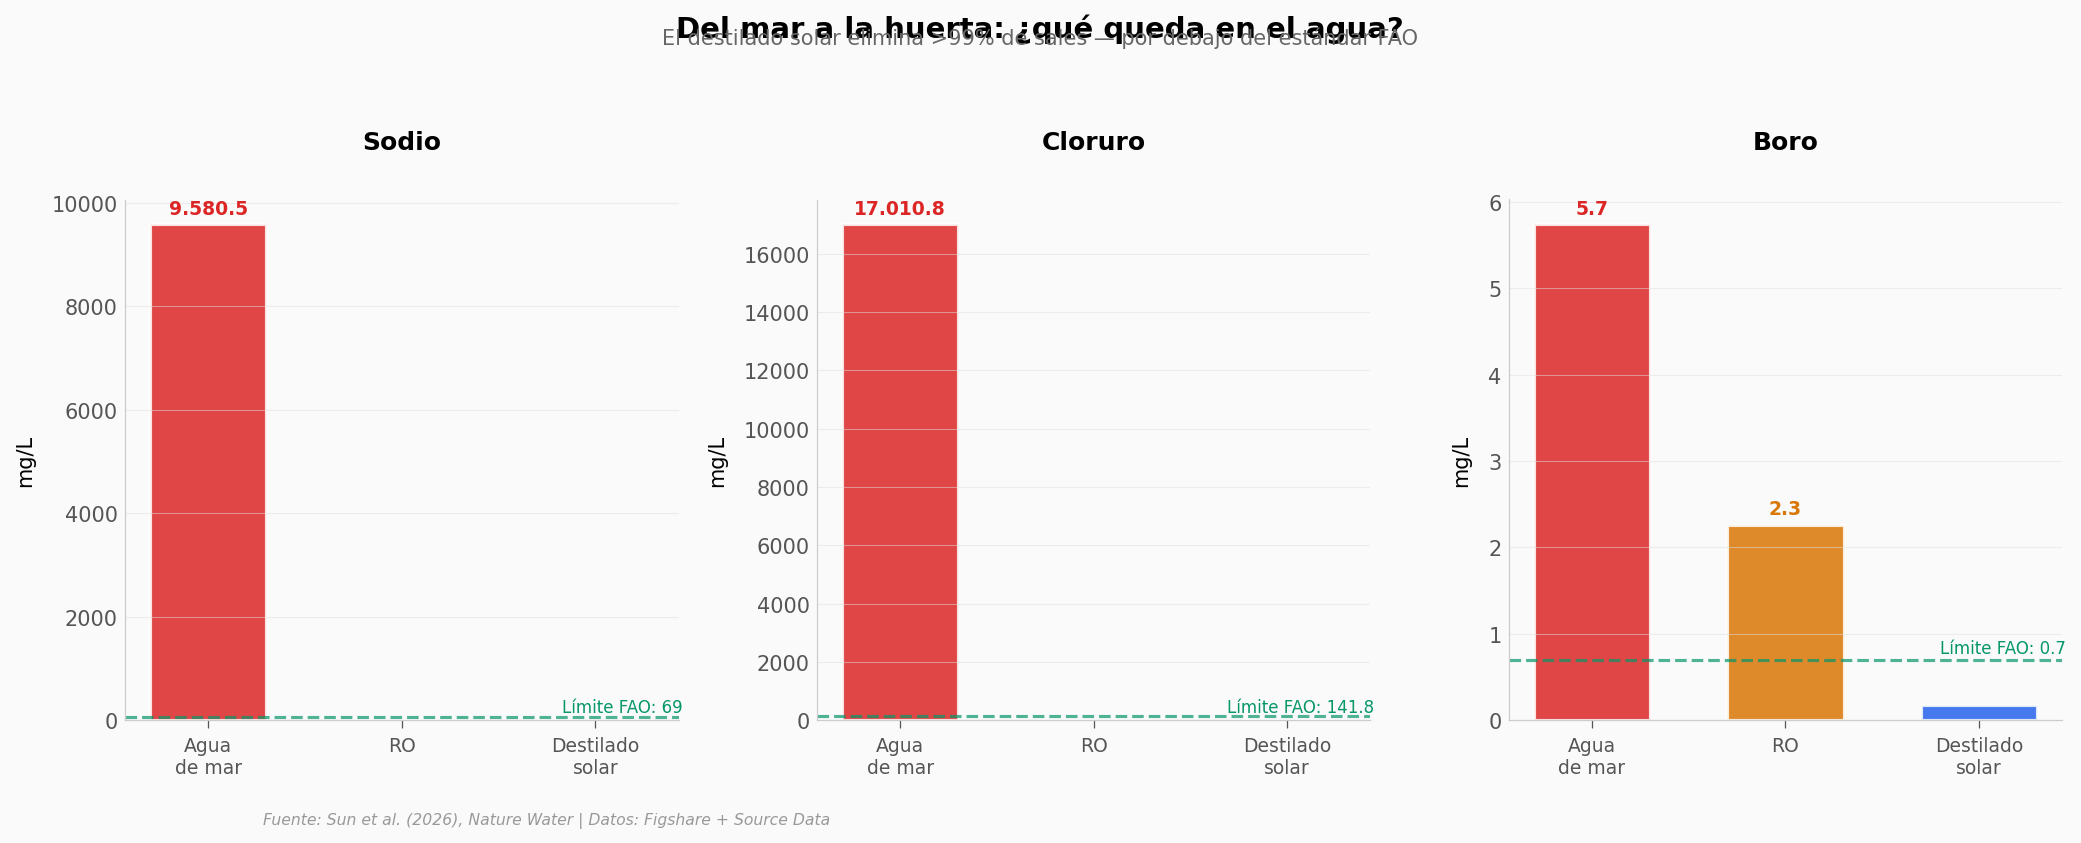

In [3]:
# Calidad del agua: mar vs RO vs solar
params = ['Sodium', 'Chloride', 'Boron']
param_labels = ['Sodio', 'Cloruro', 'Boro']
fao_limits = [69, 141.8, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (param, label, fao) in enumerate(zip(params, param_labels, fao_limits)):
    ax = axes[i]
    row = df_calidad[df_calidad['parametro'] == param].iloc[0]
    
    values = [float(row['agua_mar']), float(row['ro']), float(row['destilado_solar'])]
    colors_bar = [COLOR_NATURAL, COLOR_RO, COLOR_SOLAR]
    labels_bar = ['Agua\nde mar', 'RO', 'Destilado\nsolar']
    
    bars = ax.bar(range(3), values, color=colors_bar, width=0.6, alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    
    # FAO limit line
    ax.axhline(y=fao, color='#059669', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.text(2.45, fao * 1.05, f'Límite FAO: {fao}', fontsize=8,
            color='#059669', ha='right', va='bottom')
    
    # Value labels
    for j, v in enumerate(values):
        if v > ax.get_ylim()[1] * 0.1:
            ax.text(j, v + ax.get_ylim()[1] * 0.02, f'{v:,.1f}'.replace(',', '.'),
                    ha='center', fontsize=9, fontweight='bold', color=colors_bar[j])
    
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels_bar, fontsize=9)
    ax.set_ylabel('mg/L', fontsize=10)
    ax.set_title(label, fontsize=12, fontweight='bold')

fig.suptitle('Del mar a la huerta: ¿qué queda en el agua?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'El destilado solar elimina >99% de sales — por debajo del estándar FAO',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/calidad_agua.png', dpi=200, bbox_inches='tight')
plt.show()

El agua de mar tiene 9.581 mg/L de sodio. Después de la desalinización solar, quedan **1,27 mg/L** — una reducción del 99,99%. El boro baja de 5,74 a 0,18 mg/L, muy por debajo del límite FAO de 0,7 mg/L.

¿Por qué importa el boro? La ósmosis inversa convencional tiene problemas para eliminarlo (2,26 mg/L, todavía **3× por encima del límite** FAO). El destilado solar lo resuelve porque la evaporación deja atrás al boro.

## No solo soja

No solo soja. Probaron cuatro especies en suelo salino remediado con agua solar.

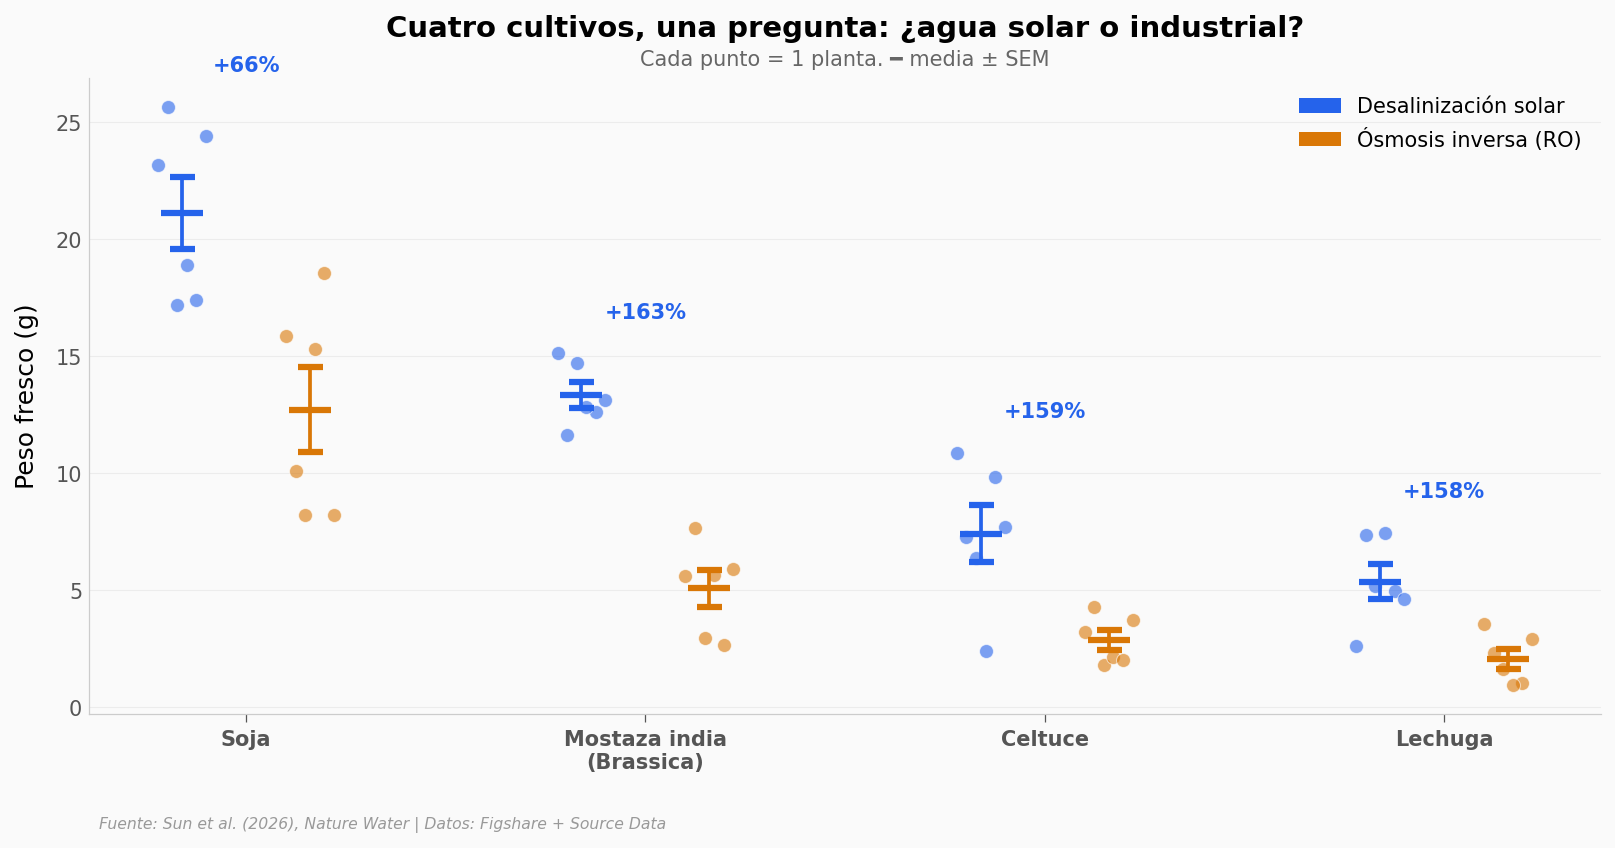

In [4]:
# Rendimiento multi-cultivo: solar vs RO
fig, ax = plt.subplots(figsize=(13, 5.5))

cultivos_order = ['Soja (Glycine max)', 'Brassica juncea', 'Celtuce', 'Lactuca sativa']
cultivos_labels = ['Soja', 'Mostaza india\n(Brassica)', 'Celtuce', 'Lechuga']

np.random.seed(42)
positions_solar = np.array([0, 2.5, 5, 7.5])
positions_ro = positions_solar + 0.8

for cultivo, pos_s, pos_r, label in zip(cultivos_order, positions_solar, positions_ro, cultivos_labels):
    sol = df_cultivos[(df_cultivos['cultivo'] == cultivo) & (df_cultivos['metodo'] == 'solar')]['peso_fresco_g']
    ro = df_cultivos[(df_cultivos['cultivo'] == cultivo) & (df_cultivos['metodo'] == 'ro')]['peso_fresco_g']
    
    # Jitter strips
    n_s = len(sol)
    n_r = len(ro)
    x_s = np.linspace(pos_s - 0.15, pos_s + 0.15, n_s)
    np.random.shuffle(x_s)
    x_r = np.linspace(pos_r - 0.15, pos_r + 0.15, n_r)
    np.random.shuffle(x_r)
    
    ax.scatter(x_s, sol.values, color=COLOR_SOLAR, s=45, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    ax.scatter(x_r, ro.values, color=COLOR_RO, s=45, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    
    # Mean ± SEM
    for data, pos, color in [(sol, pos_s, COLOR_SOLAR), (ro, pos_r, COLOR_RO)]:
        mean = data.mean()
        sem = data.std(ddof=1) / np.sqrt(len(data))
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                    markersize=20, markeredgewidth=3,
                    capsize=6, capthick=1.5, zorder=6)

# Custom x labels
mid_positions = (positions_solar + positions_ro) / 2
ax.set_xticks(mid_positions)
ax.set_xticklabels(cultivos_labels, fontsize=10, fontweight='bold')

# Percentage difference annotations
for cultivo, pos_mid in zip(cultivos_order, mid_positions):
    sol = df_cultivos[(df_cultivos['cultivo'] == cultivo) & (df_cultivos['metodo'] == 'solar')]['peso_fresco_g']
    ro = df_cultivos[(df_cultivos['cultivo'] == cultivo) & (df_cultivos['metodo'] == 'ro')]['peso_fresco_g']
    diff_pct = ((sol.mean() - ro.mean()) / ro.mean()) * 100
    y_pos = max(sol.max(), ro.max()) + 1.5
    ax.text(pos_mid, y_pos, f'+{diff_pct:.0f}%', ha='center', fontsize=10,
            fontweight='bold', color=COLOR_SOLAR)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_SOLAR, label='Desalinización solar'),
                   Patch(facecolor=COLOR_RO, label='Ósmosis inversa (RO)')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=0.9)

ax.set_ylabel('Peso fresco (g)', fontsize=12)
ax.set_title('Cuatro cultivos, una pregunta: ¿agua solar o industrial?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto = 1 planta. ━ media ± SEM',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_cultivos.png', dpi=200, bbox_inches='tight')
plt.show()

En los cuatro cultivos, las plantas regadas con destilado solar producen **más biomasa** que las regadas con RO: +66% en soja (t p = 0,005, d = 2,05), +163% en mostaza india (p < 0,0001, d = 5,04), +159% en celtuce (p = 0,005, d = 2,04), +158% en lechuga (p = 0,003, d = 2,21) — todos efectos grandes.

¿Por qué el agua solar gana al RO? La clave está en el boro. El RO deja 2,26 mg/L de boro (por encima del límite FAO), mientras que el destilado solar lo baja a 0,18 mg/L. El boro en exceso es tóxico para las plantas — y se nota en la cosecha.

## ¿Cuántas personas alimenta un campo solar?

Escalaron los números a 0,6 hectáreas — la superficie agrícola media por persona en el mundo.

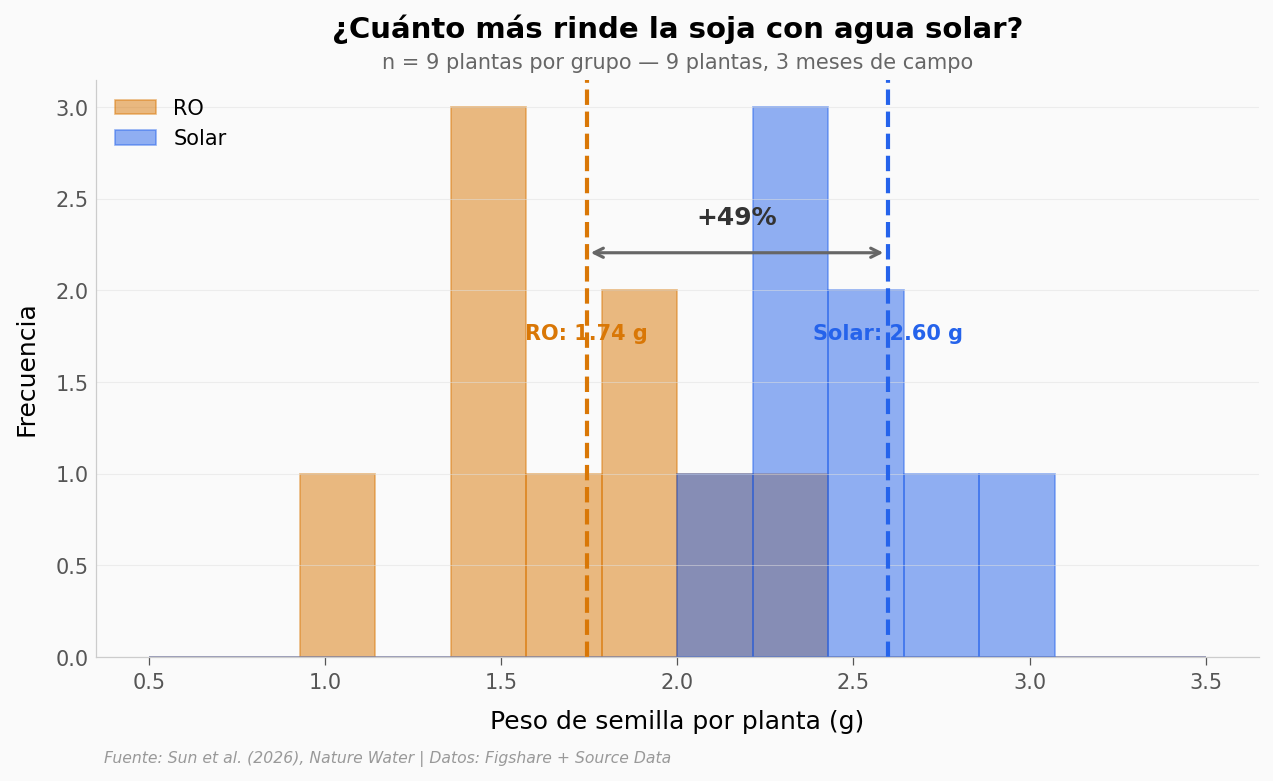


Escalado a 0,6 ha (superficie agrícola promedio por persona):
  → Agua: necesidades de 1.853 personas
  → Proteína: necesidades de 237 personas
  → Alimento seco: necesidades de 47 personas


In [5]:
# Histograma: distribución del rendimiento de soja (solar vs RO)
fig, ax = plt.subplots(figsize=(10, 5))

sol_seeds = df_soja[df_soja['metodo'] == 'solar']['peso_semilla_g']
ro_seeds = df_soja[df_soja['metodo'] == 'ro']['peso_semilla_g']

# Histograma combinado
bins = np.linspace(0.5, 3.5, 15)
ax.hist(ro_seeds, bins=bins, color=COLOR_RO, alpha=0.5, edgecolor=COLOR_RO,
        linewidth=0.8, label='RO')
ax.hist(sol_seeds, bins=bins, color=COLOR_SOLAR, alpha=0.5, edgecolor=COLOR_SOLAR,
        linewidth=0.8, label='Solar')

# Medias
ax.axvline(x=ro_seeds.mean(), color=COLOR_RO, linewidth=2, linestyle='--')
ax.axvline(x=sol_seeds.mean(), color=COLOR_SOLAR, linewidth=2, linestyle='--')

# Anotaciones
y_max = ax.get_ylim()[1]
ax.annotate('', xy=(sol_seeds.mean(), y_max*0.7),
            xytext=(ro_seeds.mean(), y_max*0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_pct = ((sol_seeds.mean() - ro_seeds.mean()) / ro_seeds.mean()) * 100
ax.text((sol_seeds.mean() + ro_seeds.mean()) / 2, y_max * 0.75,
        f'+{diff_pct:.0f}%', ha='center', fontsize=12, fontweight='bold',
        color='#333333')

ax.text(ro_seeds.mean(), y_max * 0.55, f'RO: {ro_seeds.mean():.2f} g',
        ha='center', fontsize=10, fontweight='bold', color=COLOR_RO)
ax.text(sol_seeds.mean(), y_max * 0.55, f'Solar: {sol_seeds.mean():.2f} g',
        ha='center', fontsize=10, fontweight='bold', color=COLOR_SOLAR)

ax.set_xlabel('Peso de semilla por planta (g)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('¿Cuánto más rinde la soja con agua solar?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'n = {len(sol_seeds)} plantas por grupo — 9 plantas, 3 meses de campo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_semilla.png', dpi=200, bbox_inches='tight')
plt.show()

# Números de escalado
print(f"\nEscalado a 0,6 ha (superficie agrícola promedio por persona):")
print(f"  → Agua: necesidades de {1853:,} personas".replace(",", "."))
print(f"  → Proteína: necesidades de {237} personas")
print(f"  → Alimento seco: necesidades de {PERSONAS_ALIMENTADAS} personas")

Cada planta solar produce un 49% más de semilla que una planta RO (2,60 g vs 1,74 g, Mann-Whitney p = 0,002, d = 2,01).

El escalado a 0,6 hectáreas lo pone en perspectiva: el sistema produciría agua para las necesidades de 1.853 personas, proteína para 237, y alimento seco para 47. El cuello de botella no es el agua — es la tierra.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las plantas solares crecen más que las de evaporación natural | ✅ | +134%, d = 9,21, p < 0,0001, n = 15 por grupo |
| El agua solar es comparable o superior al RO | ✅ | +10% altura (d = 1,37, p = 0,003), +49% semilla (d = 2,01, p = 0,002) |
| El destilado solar elimina >99% del sodio | ✅ | 9.580,5 → 1,27 mg/L — reducción 99,99% |
| El boro solar está bajo el límite FAO | ✅ | 0,18 mg/L < 0,7 mg/L. RO falla: 2,26 mg/L > 0,7 |
| El sistema alimenta a 47 personas por 0,6 ha | ⚠️ | Estimación por escalado lineal, no demostrado a esa escala |
| Los cuatro cultivos crecen mejor con agua solar | ✅ | Todos p < 0,02, d > 2,0 (n = 6 plantas por cultivo por método) |
| El sistema opera estable 30 días | ✅ | Media 1,93 L/m²/h, CV = 3,6% |

> **Limitaciones:** (1) Ensayo de campo en una sola ubicación (Hainan, subtropical). (2) n = 6-15 plantas por grupo — muestras pequeñas. (3) El escalado a 47 personas es una estimación lineal que asume condiciones ideales constantes. (4) El estudio compara con evaporación natural y RO, no con riego convencional de agua dulce.

## Ahora tú

1. **¿Cuánto varía la productividad solar?** Los datos de `estabilidad_operacion.csv` tienen 30 días de mediciones. ¿Hay algún patrón temporal? ¿Se degrada el sistema? Prueba graficando con `ax.plot()` y busca tendencias.

2. **¿Qué cultivo se beneficia más?** Los porcentajes de diferencia solar/RO varían (66% soja vs 163% mostaza). ¿Es porque la soja es más tolerante al boro o porque la mostaza es más sensible? Compara los pesos secos en `rendimiento_cultivos.csv`.

3. **¿Cómo cambia la sal del suelo?** En `remediacion_suelo.csv` hay datos de conductividad eléctrica durante 15 días de riego solar. ¿En qué día baja del umbral de 4 mS/cm para cultivo? Grafícalo con una línea horizontal de referencia.

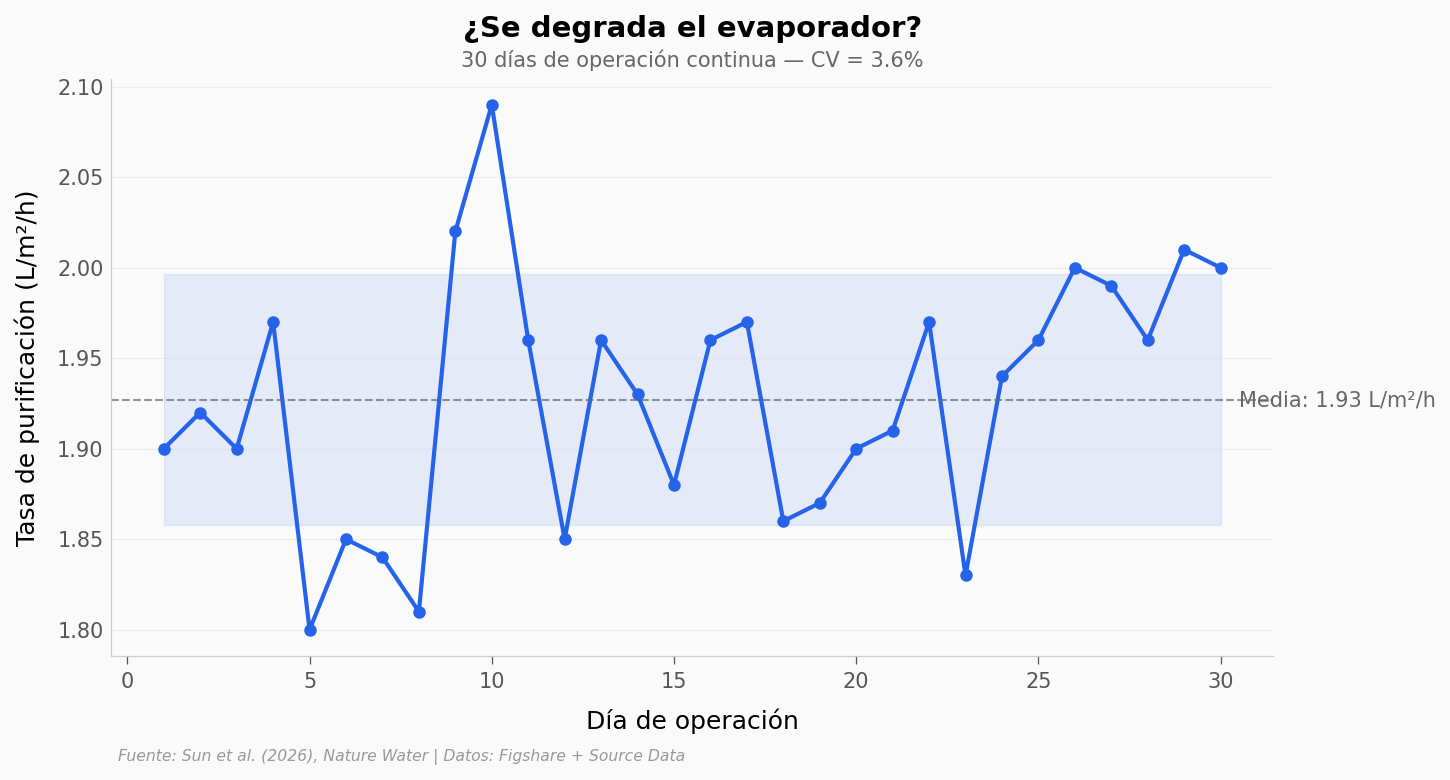

Tasa media: 1.93 ± 0.07 L/m²/h
Coeficiente de variación: 3.6%
Min: 1.80, Max: 2.09


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Es estable el evaporador solar? 30 días de operación continua

fig, ax = plt.subplots(figsize=(10, 5))

dias_op = df_estabilidad['dia']
tasa = df_estabilidad['tasa_purificacion_l_m2_h']

ax.plot(dias_op, tasa, '-o', color=COLOR_SOLAR, linewidth=2, markersize=5)
ax.axhline(y=tasa.mean(), color='#666666', linewidth=1, linestyle='--', alpha=0.7)
ax.fill_between(dias_op, tasa.mean() - tasa.std(), tasa.mean() + tasa.std(),
                alpha=0.1, color=COLOR_SOLAR)

ax.text(dias_op.iloc[-1] + 0.5, tasa.mean(), f'Media: {tasa.mean():.2f} L/m²/h',
        fontsize=10, color='#666666', va='center')

ax.set_xlabel('Día de operación', fontsize=12)
ax.set_ylabel('Tasa de purificación (L/m²/h)', fontsize=12)
ax.set_title('¿Se degrada el evaporador?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'30 días de operación continua — CV = {tasa.std()/tasa.mean()*100:.1f}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estabilidad.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Tasa media: {tasa.mean():.2f} ± {tasa.std():.2f} L/m²/h")
print(f"Coeficiente de variación: {tasa.std()/tasa.mean()*100:.1f}%")
print(f"Min: {tasa.min():.2f}, Max: {tasa.max():.2f}")

---

### Créditos

- **Paper:** Sun, Z. et al. (2026). *Solar-powered circular desalination agriculture enabled by amyloid fibril-based bioevaporators*. Nature Water.
- **DOI:** [10.1038/s44221-026-00615-y](https://doi.org/10.1038/s44221-026-00615-y)
- **Datos:** [Figshare](https://doi.org/10.6084/m9.figshare.30962279) + Source Data (CC BY 4.0)
- **Código:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)